In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# inciso a

# párametro 
N = 1000          # Número total de puntos
fs = 1000.0       # Frecuencia de muestreo (Hz) - cuántos puntos por segundo
f1 = 30.0         # Primera frecuencia (Hz)
f2 = 170.0        # Segunda frecuencia (Hz)

t_n = np.linspace(0.0, N/fs, N, endpoint=False)

#construimos señal
x_n = np.sin(2 * np.pi * f1 * t_n) + 0.5 * np.sin(2 * np.pi * f2 * t_n)


#inciso b

def dft_directa(x):
    """
    Calcula la Transformada Discreta de Fourier usando fuerza bruta (O(N^2)).
    """
    N_puntos = len(x)
    
    X_k = np.zeros(N_puntos, dtype=complex)
    
    
    for k in range(N_puntos):
        
        
        suma = 0.0
        for n in range(N_puntos):
            
            exponencial = np.exp(-1j * 2.0 * np.pi * k * n / N_puntos)
            suma += x[n] * exponencial
            
        # Guardamos el resultado de la sumatoria en el índice k
        X_k[k] = suma
        
    return X_k


X_espectro = dft_directa(x_n)

print(f"Transformada calculada. El arreglo resultante tiene {len(X_espectro)} números complejos.")

Transformada calculada. El arreglo resultante tiene 1000 números complejos.


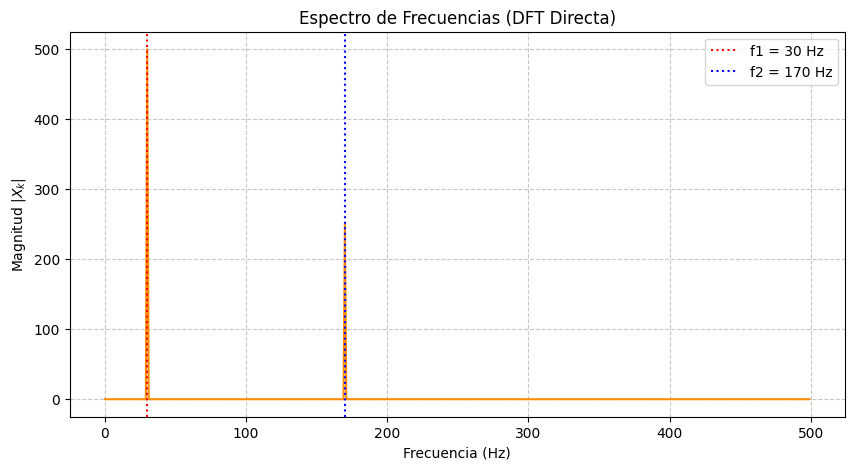

In [ ]:
# inciso c (gráfica)


magnitud_X = np.abs(X_espectro)

frecuencias = np.arange(N) * (fs / N)

mitad = N // 2

plt.figure(figsize=(10, 5))
plt.plot(frecuencias[:mitad], magnitud_X[:mitad], color='darkorange')


plt.title('Espectro de Frecuencias (DFT Directa)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud $|X_k|$')
plt.grid(True, linestyle='--', alpha=0.7)


plt.axvline(x=30, color='red', linestyle=':', label='f1 = 30 Hz')
plt.axvline(x=170, color='blue', linestyle=':', label='f2 = 170 Hz')
plt.legend()

plt.show()

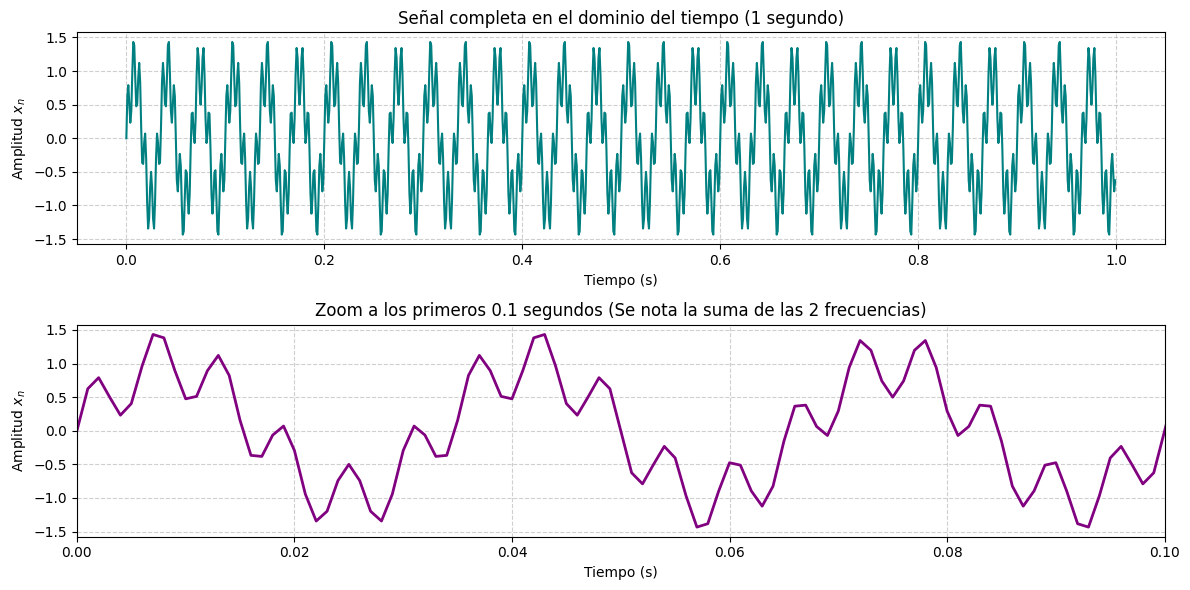

In [ ]:
# gráfico extra de la señal completa

plt.figure(figsize=(12, 6))


plt.subplot(2, 1, 1) # (2 filas, 1 columna, gráfico 1)
plt.plot(t_n, x_n, color='teal')
plt.title('Señal completa en el dominio del tiempo (1 segundo)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud $x_n$')
plt.grid(True, linestyle='--', alpha=0.6)

#gráfico com "zoom" en los primeros 0.1 segundos para ver mejor la suma de las frecuencias
plt.subplot(2, 1, 2) # (2 filas, 1 columna, gráfico 2)
plt.plot(t_n, x_n, color='purple', linewidth=2)
plt.title('Zoom a los primeros 0.1 segundos (Se nota la suma de las 2 frecuencias)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud $x_n$')
plt.xlim(0, 0.1) # Limitamos el eje X para hacer el zoom
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.show()

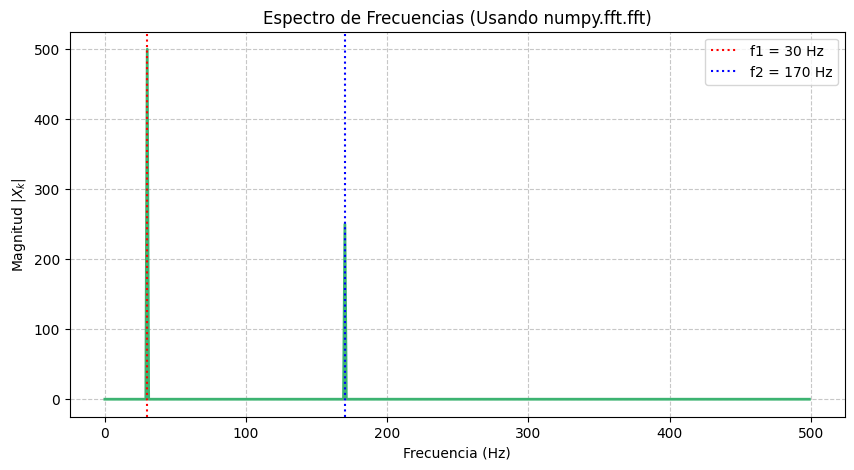

In [ ]:
# inciso d

# cálculo de fft
X_fft = np.fft.fft(x_n)

magnitud_fft = np.abs(X_fft)


plt.figure(figsize=(10, 5))


plt.plot(frecuencias[:mitad], magnitud_fft[:mitad], color='mediumseagreen', linewidth=2)

plt.title('Espectro de Frecuencias (Usando numpy.fft.fft)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud $|X_k|$')
plt.grid(True, linestyle='--', alpha=0.7)

# Destacamos las frecuencias esperadas
plt.axvline(x=30, color='red', linestyle=':', label='f1 = 30 Hz')
plt.axvline(x=170, color='blue', linestyle=':', label='f2 = 170 Hz')
plt.legend()

plt.show()

Iniciando carrera algorítmica con 15 repeticiones por N...
Evaluando N = 100   ... ¡Listo! (Promedio DFT: 0.00993 s)
Evaluando N = 500   ... ¡Listo! (Promedio DFT: 0.24118 s)
Evaluando N = 1000  ... ¡Listo! (Promedio DFT: 0.85916 s)
Evaluando N = 5000  ... ¡Listo! (Promedio DFT: 17.81500 s)
Evaluando N = 10000 ... ¡Listo! (Promedio DFT: 72.11690 s)

¡Experimento terminado exitosamente!


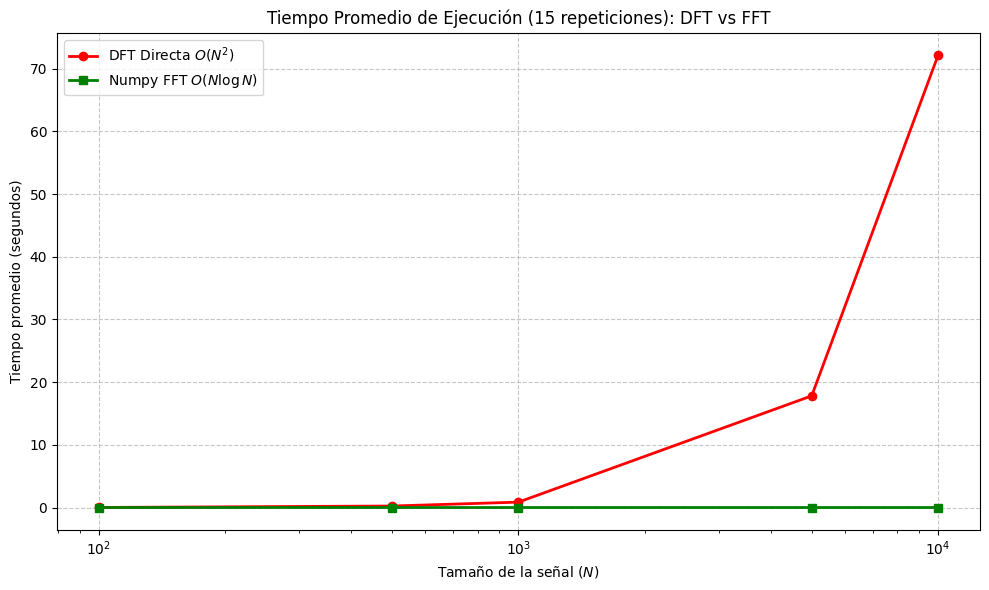

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

#inciso e

# Tamaños de la señal (agregamos algunos intermedios para mejor gráfica)
N_valores = [100, 500, 1000, 5000, 10000] 
repeticiones = 15


tiempos_dft_promedio = []
tiempos_fft_promedio = []

print(f"Iniciando carrera algorítmica con {repeticiones} repeticiones por N...")

for N_actual in N_valores:
    print(f"Evaluando N = {N_actual:<6}...", end=" ")
    
    
    tiempos_dft_temp = []
    tiempos_fft_temp = []
    
    
    t = np.linspace(0, 1, N_actual)
    senal_prueba = np.sin(2 * np.pi * 50 * t)
    
    
    for _ in range(repeticiones):
        
        # cronometro dft
        inicio_dft = time.perf_counter()
        dft_directa(senal_prueba)
        fin_dft = time.perf_counter()
        tiempos_dft_temp.append(fin_dft - inicio_dft)
        
        # cronometro fft
        inicio_fft = time.perf_counter()
        np.fft.fft(senal_prueba)
        fin_fft = time.perf_counter()
        tiempos_fft_temp.append(fin_fft - inicio_fft)
        
    
    promedio_dft = np.mean(tiempos_dft_temp)
    promedio_fft = np.mean(tiempos_fft_temp)
    
    tiempos_dft_promedio.append(promedio_dft)
    tiempos_fft_promedio.append(promedio_fft)
    
    print(f"¡Listo! (Promedio DFT: {promedio_dft:.5f} s)")

print("\n¡Experimento terminado exitosamente!")

# inciso f

plt.figure(figsize=(10, 6))

plt.plot(N_valores, tiempos_dft_promedio, marker='o', color='red', linewidth=2, label='DFT Directa $O(N^2)$')
plt.plot(N_valores, tiempos_fft_promedio, marker='s', color='green', linewidth=2, label='Numpy FFT $O(N \log N)$')

plt.title(f'Tiempo Promedio de Ejecución ({repeticiones} repeticiones): DFT vs FFT')
plt.xlabel('Tamaño de la señal ($N$)')
plt.ylabel('Tiempo promedio (segundos)')

# Eje X en escala logarítmica
plt.xscale('log') 

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.show()

--- RESULTADOS INCISO G ---
Exponente experimental DFT: 1.92 (Teórico esperado ~ 2.0)
Exponente experimental FFT: 0.24 (Teórico esperado ~ 1.0)


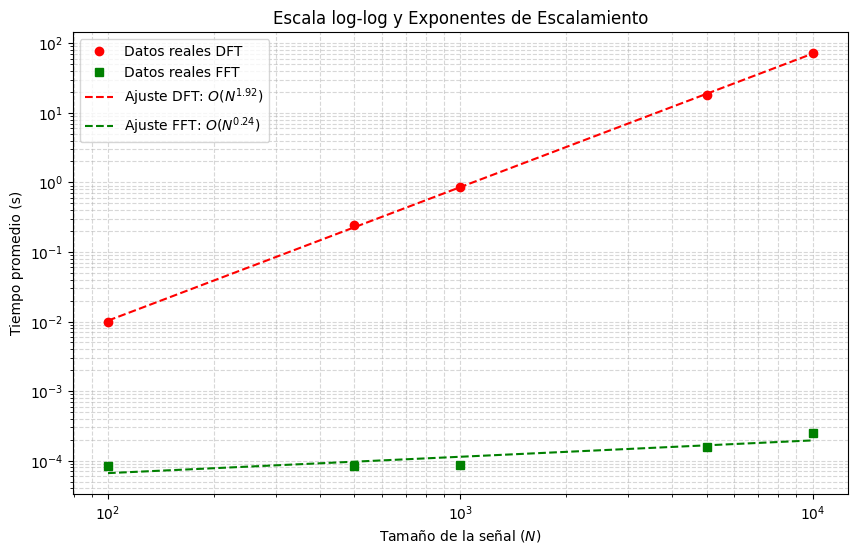


--- RESULTADOS INCISO H ---
La FFT se vuelve al menos 100 veces más rápida que la DFT directa para un tamaño de señal aproximado de: N ≈ 76 puntos


In [ ]:
# inciso g 
import numpy as np
import matplotlib.pyplot as plt

log_N = np.log10(N_valores)
log_T_dft = np.log10(tiempos_dft_promedio)
log_T_fft = np.log10(tiempos_fft_promedio)

m_dft, c_dft = np.polyfit(log_N, log_T_dft, 1)
m_fft, c_fft = np.polyfit(log_N, log_T_fft, 1)

print("inciso g")
print(f"Exponente experimental DFT: {m_dft:.2f} (Teórico esperado ~ 2.0)")
print(f"Exponente experimental FFT: {m_fft:.2f} (Teórico esperado ~ 1.0)")


plt.figure(figsize=(10, 6))


plt.loglog(N_valores, tiempos_dft_promedio, 'ro', label='Datos reales DFT')
plt.loglog(N_valores, tiempos_fft_promedio, 'gs', label='Datos reales FFT')

# T = 10^c * N^m
ajuste_dft = (10**c_dft) * (np.array(N_valores)**m_dft)
ajuste_fft = (10**c_fft) * (np.array(N_valores)**m_fft)

plt.loglog(N_valores, ajuste_dft, 'r--', label=f'Ajuste DFT: $O(N^{{{m_dft:.2f}}})$')
plt.loglog(N_valores, ajuste_fft, 'g--', label=f'Ajuste FFT: $O(N^{{{m_fft:.2f}}})$')

plt.title('Escala log-log y Exponentes de Escalamiento')
plt.xlabel('Tamaño de la señal ($N$)')
plt.ylabel('Tiempo promedio (s)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# Valor para que fft sea 100 veces más rápida que dft

# T_dft / T_fft = 100
# (10^c_dft * N^m_dft) / (10^c_fft * N^m_fft) = 100
log_N_100x = (2.0 + c_fft - c_dft) / (m_dft - m_fft)
N_100x = 10**log_N_100x

print("\ninciso h")
print(f"La FFT se vuelve al menos 100 veces más rápida que la DFT directa para un tamaño de señal aproximado de: N ≈ {int(N_100x)} puntos")

In [ ]:
import numpy as np
import time

# Celda extra para comprobar la diferencia de tiempos con N = 76
def dft_directa(x):
    N_puntos = len(x)
    X_k = np.zeros(N_puntos, dtype=complex)
    for k in range(N_puntos):
        suma = 0.0
        for n in range(N_puntos):
            exponencial = np.exp(-1j * 2.0 * np.pi * k * n / N_puntos)
            suma += x[n] * exponencial
        X_k[k] = suma
    return X_k



N_prueba = 76
repeticiones = 100 # Aumentamos las repeticiones para promediar el ruido del sistema

print(f"Realizando {repeticiones} mediciones para N = {N_prueba}...")

# 1. Creamos la señal de 80 puntos
t = np.linspace(0, 1, N_prueba)
senal_prueba = np.sin(2 * np.pi * 50 * t)

# 2. Cronometramos la DFT directa
tiempos_dft = []
for _ in range(repeticiones):
    inicio = time.perf_counter()
    dft_directa(senal_prueba)
    fin = time.perf_counter()
    tiempos_dft.append(fin - inicio)

promedio_dft = np.mean(tiempos_dft)

# 3. Cronometramos la FFT de Numpy
tiempos_fft = []
for _ in range(repeticiones):
    inicio = time.perf_counter()
    np.fft.fft(senal_prueba)
    fin = time.perf_counter()
    tiempos_fft.append(fin - inicio)

promedio_fft = np.mean(tiempos_fft)

# 4. Calculamos cuántas veces más rápido es
ratio = promedio_dft / promedio_fft

print("\n--- RESULTADOS ---")
print(f"Tiempo promedio DFT: {promedio_dft:.7f} segundos")
print(f"Tiempo promedio FFT: {promedio_fft:.7f} segundos")
print(f"Conclusión: Para N={N_prueba}, la FFT de Numpy es {ratio:.1f} veces más rápida.")

Realizando 100 mediciones para N = 76...

--- RESULTADOS ---
Tiempo promedio DFT: 0.0126054 segundos
Tiempo promedio FFT: 0.0000205 segundos
Conclusión: Para N=76, la FFT de Numpy es 615.0 veces más rápida.
